# Project 4: Data Visualisation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [2]:
# ----------------------------------------------------------------------
# Step 0-- Setup and Load Dataset
# ----------------------------------------------------------------------
INPUT_FILE = "Cleaned_Dataset.xlsx"

# Colors (per "Color is a tool for highlighting, not decoration")
HIGHLIGHT = "#1f4e8c"   # single accent color (navy/blue)
NEUTRAL = "#b0b0b0"     # muted grey for context bars/points
TEXT_DARK = "#222222"

plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.grid": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

df = pd.read_excel(INPUT_FILE)
df["Date"] = pd.to_datetime(df["Date"])

## Project Objective

This project uses data visualisation to convert order-level sales data into clear business insights. The analysis focuses on revenue trend, product performance, basket behaviour, referral source effectiveness, seasonality, and management recommendations.

In [3]:
# ----------------------------------------------------------------------
# Step 1- Data Quality and Preparation Check
# ----------------------------------------------------------------------

# Make sure Date column is in datetime format
df["Date"] = pd.to_datetime(df["Date"])

print("=" * 70)
print("DATA QUALITY CHECK")
print("=" * 70)

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]:,}")
print(f"Date range: {df['Date'].min().strftime('%d %b %Y')} to {df['Date'].max().strftime('%d %b %Y')}")

print("\nMissing values by column:")
print(df.isna().sum())

print("\nDuplicate Order IDs:")
print(df["OrderID"].duplicated().sum())

print("\nColumn names:")
print(df.columns.tolist())

DATA QUALITY CHECK
Number of rows: 1,200
Number of columns: 14
Date range: 01 Jan 2023 to 30 Jun 2025

Missing values by column:
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

Duplicate Order IDs:
0

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']


In [4]:
# ----------------------------------------------------------------------
# Create Monthly Revenue Series
# This is needed for the KPI summary and later charts
# ----------------------------------------------------------------------

monthly_revenue = (
    df.groupby(pd.Grouper(key="Date", freq="MS"))["TotalPrice"]
    .sum()
)

monthly_revenue.head()

Date
2023-01-01    56685.75
2023-02-01    40117.66
2023-03-01    48609.37
2023-04-01    27751.71
2023-05-01    63836.84
Freq: MS, Name: TotalPrice, dtype: float64

In [5]:
# ----------------------------------------------------------------------
# Step 2- executive KPI Summary
# ----------------------------------------------------------------------

total_revenue = df["TotalPrice"].sum()
total_orders = df["OrderID"].nunique()
average_order_value = total_revenue / total_orders
average_cart_size = df["ItemsInCart"].mean()

peak_month = monthly_revenue.idxmax()
peak_month_revenue = monthly_revenue.max()

top_product = df.groupby("Product")["TotalPrice"].sum().idxmax()
top_product_revenue = df.groupby("Product")["TotalPrice"].sum().max()

top_channel = df.groupby("ReferralSource")["OrderID"].count().idxmax()
top_channel_orders = df.groupby("ReferralSource")["OrderID"].count().max()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Average Order Value",
        "Average Cart Size",
        "Peak Revenue Month",
        "Top Product",
        "Top Referral Channel"
    ],
    "Result": [
        f"${total_revenue:,.0f}",
        f"{total_orders:,}",
        f"${average_order_value:,.2f}",
        f"{average_cart_size:.2f} items",
        f"{peak_month.strftime('%b %Y')} (${peak_month_revenue:,.0f})",
        f"{top_product} (${top_product_revenue:,.0f})",
        f"{top_channel} ({top_channel_orders:,} orders)"
    ]
})

kpi_summary

,KPI,Result
0,Total Revenue,"$1,264,762"
1,Total Orders,"1,200"
2,Average Order Value,"$1,053.97"
3,Average Cart Size,5.49 items
4,Peak Revenue Month,"Jun 2024 ($68,069)"
5,Top Product,"Chair ($195,620)"
6,Top Referral Channel,Instagram (259 orders)


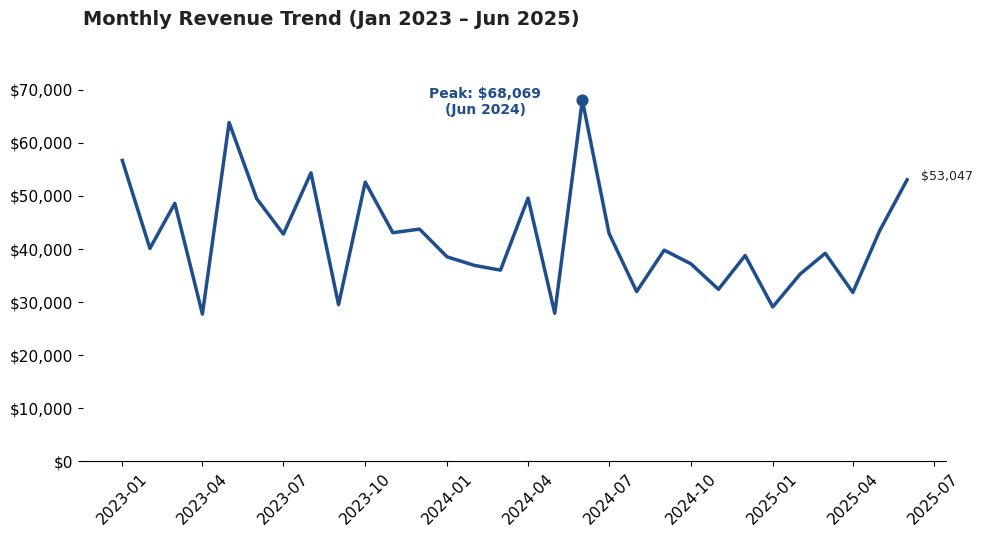

In [6]:

# ----------------------------------------------------------------------
# Chart 1: Monthly Revenue Trend
# Business question: Is revenue growing or declining over time?
# ----------------------------------------------------------------------
monthly_revenue = (
    df.set_index("Date")["TotalPrice"]
    .resample("MS")
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    color=HIGHLIGHT,
    linewidth=2.5,
)

# Direct-label the first, peak, and last points (avoid clutter/legend)
peak_date = monthly_revenue.idxmax()
peak_val = monthly_revenue.max()
first_date, first_val = monthly_revenue.index[0], monthly_revenue.iloc[0]
last_date, last_val = monthly_revenue.index[-1], monthly_revenue.iloc[-1]

ax.scatter([peak_date], [peak_val], color=HIGHLIGHT, zorder=5, s=60)
ax.annotate(
    f"Peak: ${peak_val:,.0f}\n({peak_date.strftime('%b %Y')})",
    xy=(peak_date, peak_val),
    xytext=(-70, -10),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=HIGHLIGHT,
)
ax.annotate(
    f"${last_val:,.0f}",
    xy=(last_date, last_val),
    xytext=(10, 0),
    textcoords="offset points",
    fontsize=9,
    color=TEXT_DARK,
)

pct_change = (last_val - first_val) / first_val * 100
direction = "grew" if pct_change >= 0 else "declined"

ax.set_title(
    f"Monthly Revenue Trend (Jan 2023 – Jun 2025)",
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.tick_params(axis="x", rotation=45)
ax.set_ylim(0, peak_val * 1.15)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("chart1_monthly_revenue_trend.png", dpi=200, bbox_inches="tight")
plt.show()

**Insight:** Monthly revenue declined by 6.4% from Jan 2023 to Jun 2025, after reaching its highest point in Jun 2024.

**So what?** Management should investigate whether the decline is linked to weaker product demand, lower referral performance, or seasonality.

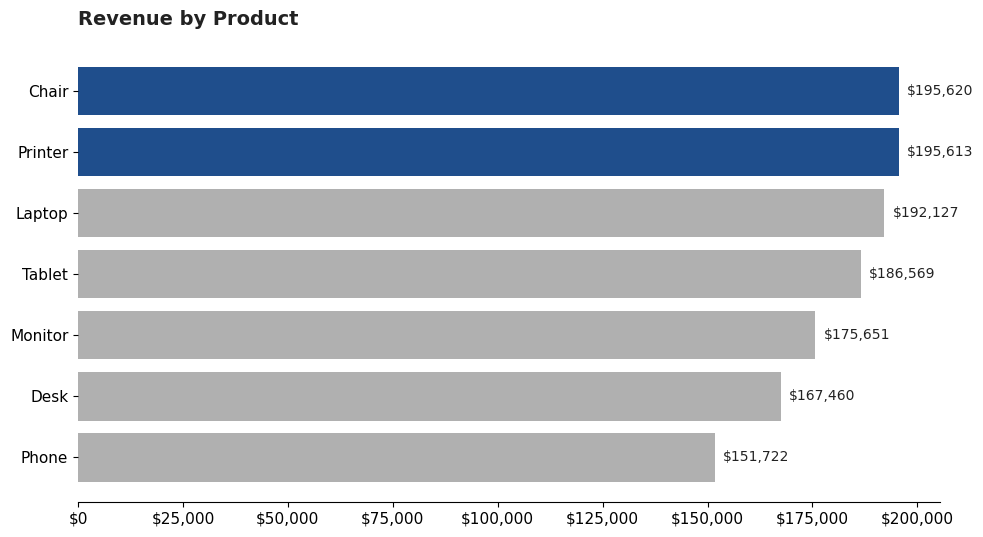

In [7]:
#  ----------------------------------------------------------------------
# Chart 2: Revenue by Product
# Business question: Which product drives the most revenue?
# ----------------------------------------------------------------------
revenue_by_product = (
    df.groupby("Product")["TotalPrice"].sum().sort_values(ascending=True)
)
top_product = revenue_by_product.idxmax()
top_value = revenue_by_product.max()
runner_up_value = revenue_by_product.iloc[-2]
runner_up = revenue_by_product.index[-2]
is_close_race = (top_value - runner_up_value) / top_value < 0.02  # within 2%

if is_close_race:
    colors = [
        HIGHLIGHT if p in (top_product, runner_up) else NEUTRAL
        for p in revenue_by_product.index
    ]
else:
    colors = [HIGHLIGHT if p == top_product else NEUTRAL for p in revenue_by_product.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(revenue_by_product.index, revenue_by_product.values, color=colors)

# Direct labels on each bar (no legend needed)
for bar, value in zip(bars, revenue_by_product.values):
    ax.text(
        value + revenue_by_product.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        fontsize=10,
        color=TEXT_DARK,
    )

top_share = top_value / revenue_by_product.sum() * 100

if is_close_race:
    title2 = (
        f"Revenue by Product"
    )
else:
    title2 = (
        f"Revenue by Product"
    )

ax.set_title(
    title2,
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15,
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlim(left=0)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("chart2_revenue_by_product.png", dpi=200, bbox_inches="tight")
plt.show()


**Insight:** Monthly revenue declined by 6.4% from Jan 2023 to Jun 2025, after reaching its highest point in Jun 2024.

**So what?** Management should investigate whether the decline is linked to weaker product demand, lower referral performance, or seasonality.

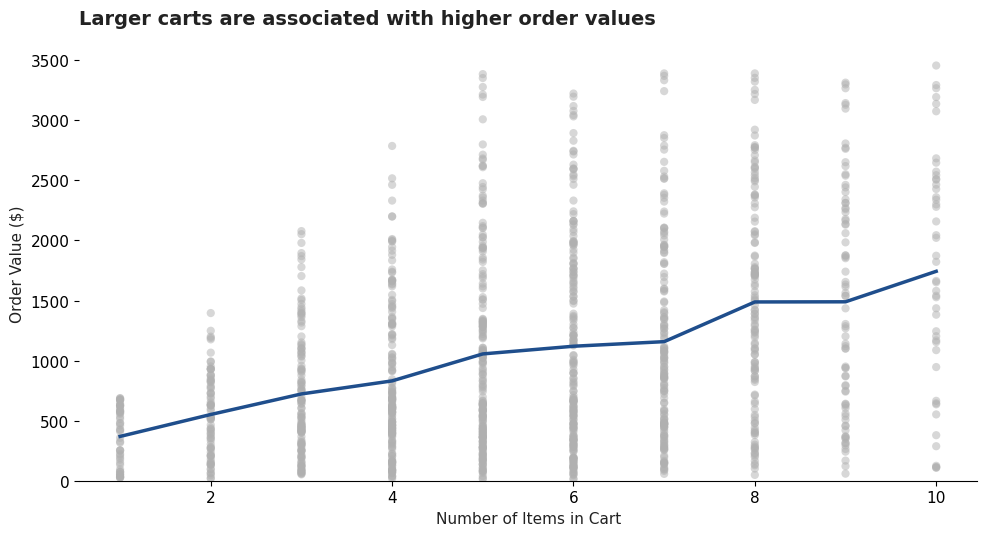

In [8]:
# ----------------------------------------------------------------------
# Chart 3: Items in Cart vs Total Price
# Business question: Does cart size relate to order value?
# ----------------------------------------------------------------------
correlation = df["ItemsInCart"].corr(df["TotalPrice"])

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(
    df["ItemsInCart"],
    df["TotalPrice"],
    color=NEUTRAL,
    alpha=0.5,
    s=35,
    edgecolors="none",
)

# Trend line to support the "relationship" insight directly
z = pd.Series(df["TotalPrice"]).groupby(df["ItemsInCart"]).mean()
ax.plot(z.index, z.values, color=HIGHLIGHT, linewidth=2.5)

strength = (
    "no meaningful" if abs(correlation) < 0.1 else
    "a weak" if abs(correlation) < 0.3 else
    "a moderate" if abs(correlation) < 0.6 else
    "a strong"
)
ax.set_title(
    "Larger carts are associated with higher order values",
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15
)

ax.set_xlabel(
    "Number of Items in Cart",
    fontsize=11,
    color=TEXT_DARK
)

ax.set_ylabel(
    "Order Value ($)",
    fontsize=11,
    color=TEXT_DARK
)
ax.set_ylim(bottom=0)
fig.tight_layout()
fig.savefig("chart3_cart_size_vs_order_value.png", dpi=200, bbox_inches="tight")
plt.show()

**Insight:** Cart size has a moderate positive relationship with total order value.

**So what?** Bundle offers and cross-selling strategies may help increase average order value.

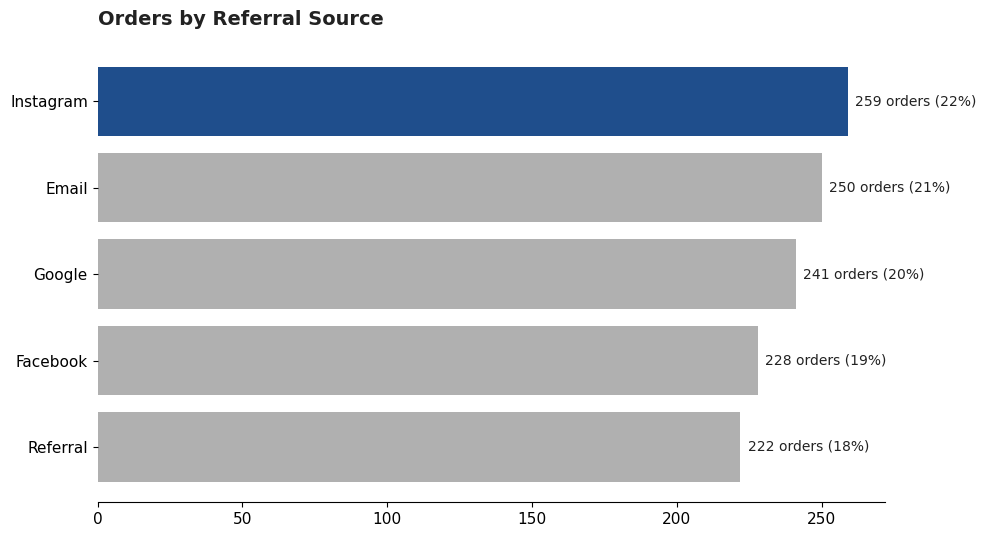

In [9]:
# ----------------------------------------------------------------------
# Chart 4: Orders by Referral Source (Horizontal Bar Chart)
# Business question: Which channel brings in the most orders?
# ----------------------------------------------------------------------
orders_by_source = (
    df.groupby("ReferralSource")["OrderID"].count().sort_values(ascending=True)
)
top_source = orders_by_source.idxmax()
colors = [HIGHLIGHT if s == top_source else NEUTRAL for s in orders_by_source.index]

fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh(orders_by_source.index, orders_by_source.values, color=colors)

for bar, value in zip(bars, orders_by_source.values):
    pct = value / orders_by_source.sum() * 100
    ax.text(
        value + orders_by_source.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,} orders ({pct:.0f}%)",
        va="center",
        fontsize=10,
        color=TEXT_DARK,
    )

top_pct = orders_by_source.max() / orders_by_source.sum() * 100
ax.set_title(
    f"Orders by Referral Source",
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15,
)
ax.set_xlim(left=0)
ax.set_xlabel("")
ax.set_ylabel("")
fig.tight_layout()
fig.savefig("chart4_orders_by_referral_source.png", dpi=200, bbox_inches="tight")
plt.show()

**Insight:** Instagram generated the highest number of orders.

**So what?** Instagram is useful for customer acquisition, but it should also be evaluated by revenue quality.

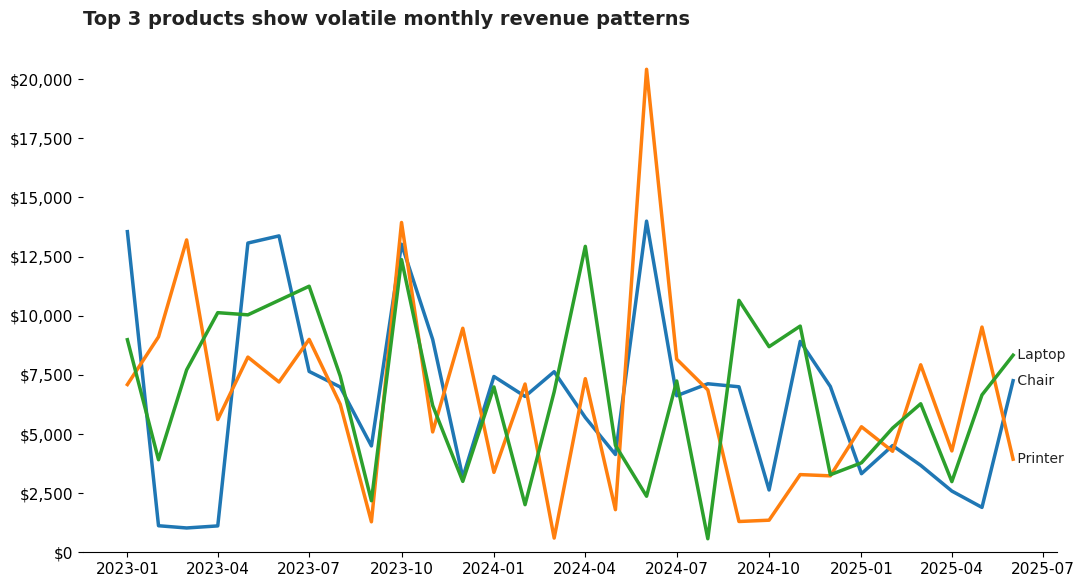

In [10]:
# ----------------------------------------------------------------------
# Chart 5: Monthly Revenue Trend for Top 3 Products
# Business question: Which products are driving revenue movement over time?
# ----------------------------------------------------------------------

top_3_products = (
    df.groupby("Product")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(3)
    .index
)

product_monthly_revenue = (
    df[df["Product"].isin(top_3_products)]
    .groupby([pd.Grouper(key="Date", freq="MS"), "Product"])["TotalPrice"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 6))

for product in top_3_products:
    product_data = product_monthly_revenue[product_monthly_revenue["Product"] == product]
    ax.plot(
        product_data["Date"],
        product_data["TotalPrice"],
        linewidth=2.5,
        label=product
    )

    last_x = product_data["Date"].iloc[-1]
    last_y = product_data["TotalPrice"].iloc[-1]

    ax.text(
        last_x,
        last_y,
        f" {product}",
        va="center",
        fontsize=10,
        color=TEXT_DARK
    )

ax.set_title(
    "Top 3 products show volatile monthly revenue patterns",
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("")
ax.set_ylabel("")
ax.legend().remove()
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig("chart5_top3_product_monthly_revenue.png", dpi=200, bbox_inches="tight")
plt.show()

**Insight:** Laptop, Chair, and Printer all show unstable monthly revenue, with noticeable peaks and drops over time. Printer produced the strongest single-month spike around mid-2024.

**So what?** The business should review product-level demand patterns before making stock or marketing decisions. Promotions and inventory planning should focus on the products that drive major revenue movements.

In [11]:
# ----------------------------------------------------------------------
# Business question: Which referral source brings the highest-value orders?
# ----------------------------------------------------------------------

source_quality = (
    df.groupby("ReferralSource")
    .agg(
        Orders=("OrderID", "count"),
        Revenue=("TotalPrice", "sum"),
        Average_Order_Value=("TotalPrice", "mean")
    )
    .sort_values("Average_Order_Value", ascending=True)
)

source_quality

,Orders,Revenue,Average_Order_Value
ReferralSource,,,
Referral,222,226815.58,1021.691802
Google,241,250441.48,1039.176266
Email,250,261808.55,1047.234200
Instagram,259,275285.45,1062.878185
Facebook,228,250410.90,1098.293421


**Insight:** Facebook produced the highest average order value.

**So what?** Facebook may attract higher-value customers, so the business should compare its campaign cost against its order value.

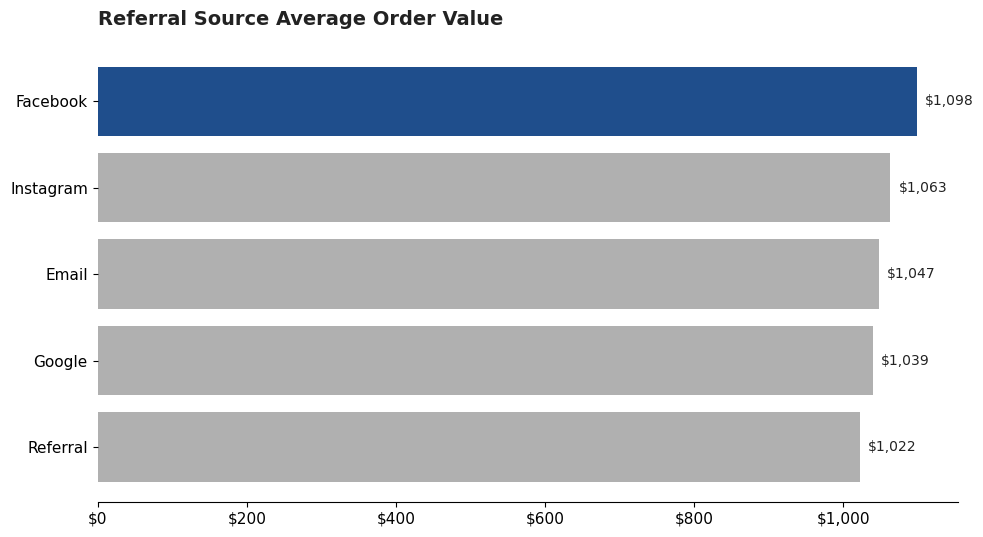

In [12]:
# -------------------------------------------------------------------
# Chart 6: Referral Source Quality
#--------------------------------------------------------------------
top_aov_source = source_quality["Average_Order_Value"].idxmax()

colors = [
    HIGHLIGHT if source == top_aov_source else NEUTRAL
    for source in source_quality.index
]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.barh(
    source_quality.index,
    source_quality["Average_Order_Value"],
    color=colors
)

for bar, value in zip(bars, source_quality["Average_Order_Value"]):
    ax.text(
        value + source_quality["Average_Order_Value"].max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"${value:,.0f}",
        va="center",
        fontsize=10,
        color=TEXT_DARK
    )

ax.set_title(
    f"Referral Source Average Order Value",
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15
)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xlim(left=0)

fig.tight_layout()
fig.savefig("chart6_referral_source_aov.png", dpi=200, bbox_inches="tight")
plt.show()

**Insight:** Facebook produced the highest average order value.

**So what?** Facebook may attract higher-value customers, so the business should compare its campaign cost against its order value.

/var/folders/qd/55gsmklx5d7_8y433cqg_q5m0000gn/T/ipykernel_44121/3351997672.py:8: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  .resample("Q")


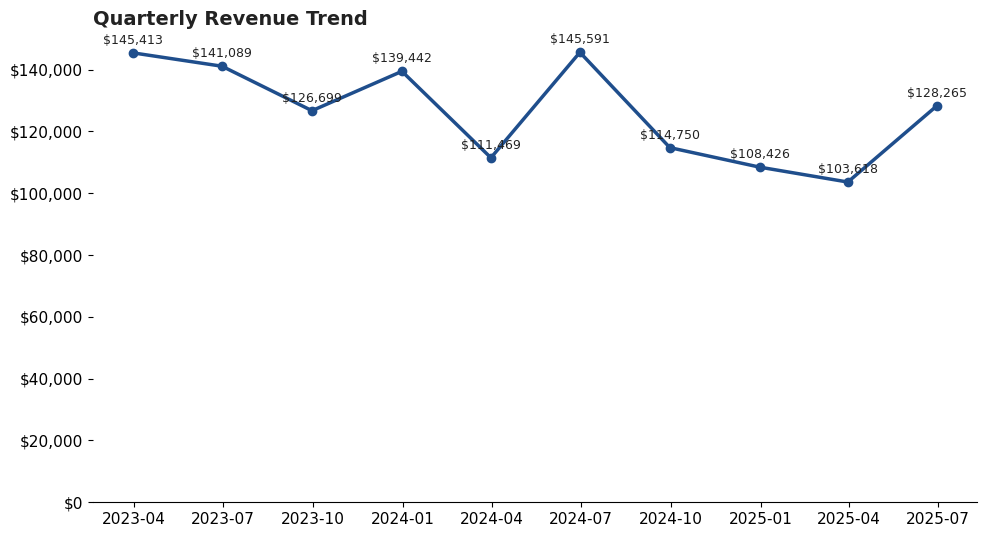

In [13]:
# ----------------------------------------------------------------------
# Chart 7: Quarterly Revenue Trend
# Business question: Is revenue affected by seasonal or quarterly patterns?
# ----------------------------------------------------------------------

quarterly_revenue = (
    df.set_index("Date")["TotalPrice"]
    .resample("Q")
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    quarterly_revenue.index,
    quarterly_revenue.values,
    color=HIGHLIGHT,
    linewidth=2.5,
    marker="o"
)

for x, y in zip(quarterly_revenue.index, quarterly_revenue.values):
    ax.text(
        x,
        y + quarterly_revenue.max() * 0.02,
        f"${y:,.0f}",
        ha="center",
        fontsize=9,
        color=TEXT_DARK
    )

best_quarter = quarterly_revenue.idxmax()
best_quarter_value = quarterly_revenue.max()

ax.set_title(
    f"Quarterly Revenue Trend",
    fontsize=14,
    fontweight="bold",
    color=TEXT_DARK,
    loc="left",
    pad=15
)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_ylim(bottom=0)

fig.tight_layout()
fig.savefig("chart7_quarterly_revenue_trend.png", dpi=200, bbox_inches="tight")
plt.show()

**Insight:** Quarterly revenue helps identify whether performance changes are seasonal or part of a wider decline.

**So what?** Management should compare quarterly patterns before deciding whether corrective action is needed.

In [14]:
# ----------------------------------------------------------------------
# Step 3- Business Recommendations
# ----------------------------------------------------------------------

recommendations = pd.DataFrame({
    "Finding": [
        f"Revenue {direction} by {abs(pct_change):.1f}% from {first_date.strftime('%b %Y')} to {last_date.strftime('%b %Y')}",
        f"{top_product} generated the highest product revenue",
        f"Cart size has {strength} relationship with order value",
        f"{top_source} generated the highest number of orders",
        f"{top_aov_source} generated the highest average order value"
    ],
    "Business Meaning": [
        "Recent sales performance needs management attention.",
        "Revenue is partly dependent on the strongest product category.",
        "Larger baskets are associated with higher order value.",
        "This channel is strong for customer acquisition volume.",
        "This channel may bring more valuable customers."
    ],
    "Recommended Action": [
        "Investigate whether the decline is caused by product demand, referral source performance, or seasonality.",
        f"Prioritise stock availability, promotion, and bundling opportunities around {top_product}.",
        "Test bundle offers, multi-item discounts, or cross-selling strategies.",
        f"Continue using {top_source}, but compare its revenue quality with other channels.",
        f"Consider increasing campaign focus on {top_aov_source} if acquisition cost is acceptable."
    ]
})

recommendations

,Finding,Business Meaning,Recommended Action
0,Revenue declined by 6.4% from Jan 2023 to Jun ...,Recent sales performance needs management atte...,Investigate whether the decline is caused by p...
1,Chair generated the highest product revenue,Revenue is partly dependent on the strongest p...,"Prioritise stock availability, promotion, and ..."
2,Cart size has a moderate relationship with ord...,Larger baskets are associated with higher orde...,"Test bundle offers, multi-item discounts, or c..."
3,Instagram generated the highest number of orders,This channel is strong for customer acquisitio...,"Continue using Instagram, but compare its reve..."
4,Facebook generated the highest average order v...,This channel may bring more valuable customers.,Consider increasing campaign focus on Facebook...


In [15]:
# ----------------------------------------------------------------------
# Step 4: Executive Summary
# ----------------------------------------------------------------------

print("=" * 80)
print("PROJECT 4: DATA VISUALIZATION - EXECUTIVE SUMMARY")
print("=" * 80)

print(f"""
SITUATION
The dataset covers orders from {df['Date'].min().strftime('%b %Y')} to {df['Date'].max().strftime('%b %Y')}.
Total revenue was ${total_revenue:,.0f} from {total_orders:,} orders, with an average order value of ${average_order_value:,.2f}.

COMPLICATION
Monthly revenue {direction} by {abs(pct_change):.1f}% from {first_date.strftime('%b %Y')} 
(${first_val:,.0f}) to {last_date.strftime('%b %Y')} (${last_val:,.0f}).
The highest revenue month was {peak_date.strftime('%b %Y')} at ${peak_val:,.0f}, meaning performance later moved away from its peak.

KEY INSIGHTS
1. Revenue Trend:
   Revenue {direction} by {abs(pct_change):.1f}% across the period.

2. Product Performance:
   {top_product} was the strongest product, generating ${top_product_revenue:,.0f} in revenue.

3. Basket Behaviour:
   Cart size had {strength} relationship with order value, with a correlation of {correlation:.3f}.
   This suggests that larger baskets are associated with higher order values.

4. Referral Source:
   {top_source} generated the highest number of orders.
   However, {top_aov_source} delivered the highest average order value.

RESOLUTION / RECOMMENDED ACTION
Management should investigate the recent revenue decline, protect the strongest product category,
compare referral channels by both order volume and order value, and test bundle-based promotions
to increase basket size and average order value.
""")

print("OUTPUT FILES")
print("- chart1_monthly_revenue_trend.png")
print("- chart2_revenue_by_product.png")
print("- chart3_cart_size_vs_order_value.png")
print("- chart4_orders_by_referral_source.png")
print("- chart5_top3_product_monthly_revenue.png")
print("- chart6_referral_source_aov.png")
print("- chart7_quarterly_revenue_trend.png")
print("- executive_kpi_summary.csv")
print("- business_recommendations.csv")


PROJECT 4: DATA VISUALIZATION - EXECUTIVE SUMMARY

SITUATION
The dataset covers orders from Jan 2023 to Jun 2025.
Total revenue was $1,264,762 from 1,200 orders, with an average order value of $1,053.97.

COMPLICATION
Monthly revenue declined by 6.4% from Jan 2023 
($56,686) to Jun 2025 ($53,047).
The highest revenue month was Jun 2024 at $68,069, meaning performance later moved away from its peak.

KEY INSIGHTS
1. Revenue Trend:
   Revenue declined by 6.4% across the period.

2. Product Performance:
   Chair was the strongest product, generating $195,620 in revenue.

3. Basket Behaviour:
   Cart size had a moderate relationship with order value, with a correlation of 0.393.
   This suggests that larger baskets are associated with higher order values.

4. Referral Source:
   Instagram generated the highest number of orders.
   However, Facebook delivered the highest average order value.

RESOLUTION / RECOMMENDED ACTION
Management should investigate the recent revenue decline, protect t

# Step 5
## Final Conclusion

The visual analysis shows that the business generated strong total revenue, but monthly revenue declined by 6.4% between Jan 2023 and Jun 2025 after peaking in Jun 2024. Chair was the strongest product by revenue, while Instagram generated the highest number of orders. However, Facebook delivered the highest average order value, showing that the best channel by volume is not necessarily the best channel by customer value.

The recommended actions are to investigate the revenue decline, protect the strongest product category, compare referral channels by both volume and value, and test bundle-based promotions to increase cart size and average order value.